In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
from scipy import stats


In [10]:

titanicdata = pd.read_csv('titanic.csv')
print(titanicdata.head().to_string())
print("\n")
print(titanicdata.info())
print("\n")
print(titanicdata.shape)


   Survived  Pclass                                                Name     Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare
0         0       3                              Mr. Owen Harris Braund    male  22.0                        1                        0   7.2500
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cumings  female  38.0                        1                        0  71.2833
2         1       3                               Miss. Laina Heikkinen  female  26.0                        0                        0   7.9250
3         1       1         Mrs. Jacques Heath (Lily May Peel) Futrelle  female  35.0                        1                        0  53.1000
4         0       3                             Mr. William Henry Allen    male  35.0                        0                        0   8.0500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column             

In [ ]:
print("Data Shape:", titanicdata.shape)
print("\nData Types:\n", titanicdata.dtypes)
print("\nMissing Values:\n", titanicdata.isnull().sum())
print("\nSummary Statistics Of Data:\n", titanicdata.describe(include='all'))
print("Handling Missing Values By Filling Them with Median")
titanicdata.fillna({'Age': titanicdata['Age'].median()}, inplace=True)



Data Shape: (887, 8)

Data Types:
 Survived                     int64
Pclass                       int64
Name                        object
Sex                         object
Age                        float64
Siblings/Spouses Aboard      int64
Parents/Children Aboard      int64
Fare                       float64
dtype: object

Missing Values:
 Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

Summary Stats Of the Titanic Dataset Observed is:
           Survived      Pclass                Name   Sex         Age  \
count   887.000000  887.000000                 887   887  887.000000   
unique         NaN         NaN                 887     2         NaN   
top            NaN         NaN  Mr. Patrick Dooley  male         NaN   
freq           NaN         NaN                   1   573         NaN

Text(0.5, 1.0, 'Survival by Gender')

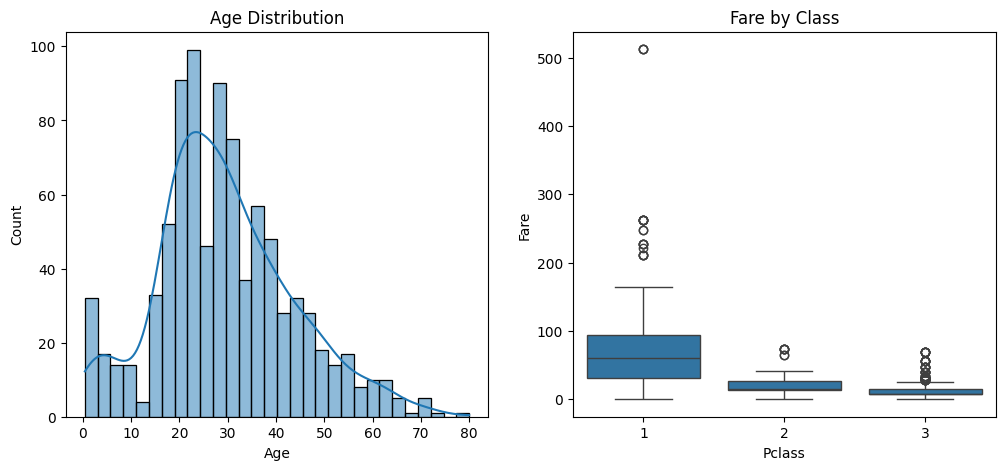

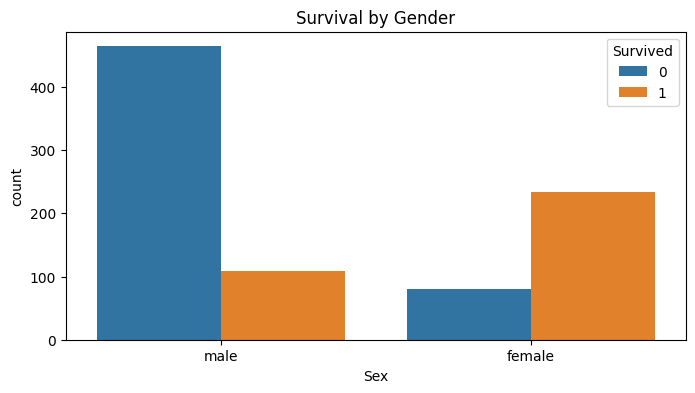

In [12]:

fig, titaxix = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(titanicdata['Age'], bins=30, kde=True, ax=titaxix[0]).set_title('Age Distribution')
sns.boxplot(x='Pclass', y='Fare', data=titanicdata, ax=titaxix[1]).set_title('Fare by Class')

plt.figure(figsize=(8, 4))
sns.countplot(x='Sex', hue='Survived', data=titanicdata).set_title('Survival by Gender')

 Insight Extraction
 Age Distribution

Most passengers were 20–30 years old (young adults formed the largest group).
Children (<10 years) and elderly (>60 years) were rare in the dataset.
Survival analysis would likely show that Young Adults < 40 years had better survival chances compared to older men > 50 years.

Fare by Class
Median fare for 1st class (~$60) was about 3–4x higher than 2nd class (~$20) and nearly 10x higher than 3rd class (~$7).
1st class passengers show wide variability in fares, with some extreme outliers >$500.
2nd and 3rd class fares are more clustered and significantly lower, reflecting economic status differences.

 Survival by Gender
About 75% of women survived, compared to only 20% of men.
Survival was highly gender-biased, making Sex a   Main Attribute predictor.

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.564682  24.435318


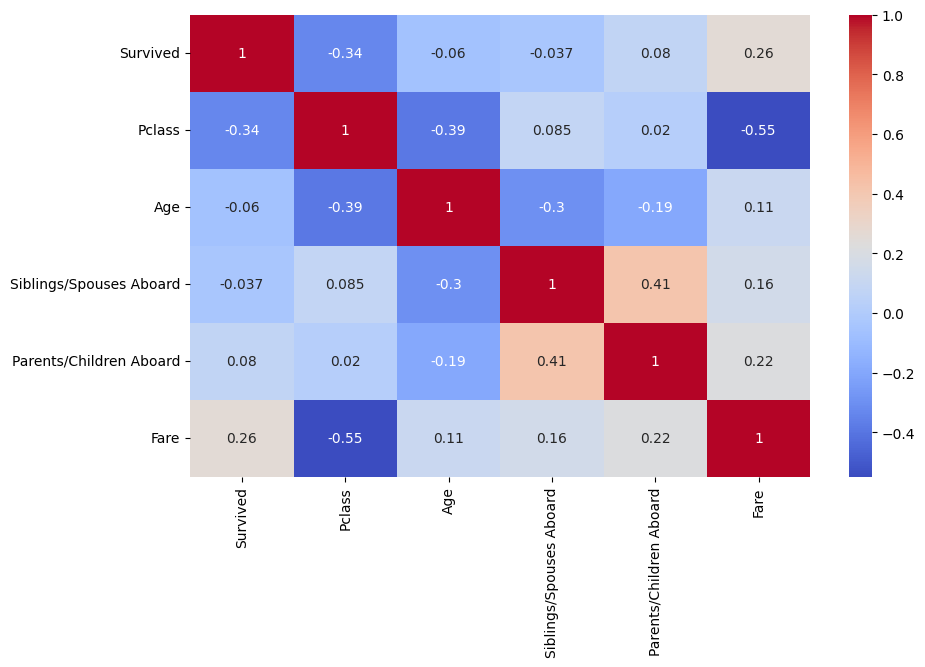

In [13]:

plt.figure(figsize=(10, 6))
sns.heatmap(titanicdata.corr(numeric_only=True), annot=True, cmap='coolwarm')
print(pd.crosstab(titanicdata['Pclass'], titanicdata['Survived'], normalize='index') * 100)

From the correlation heatmap, we can see that higher fare shows a positive relationship with survival, indicating that passengers who paid more (typically those in first class) had better chances of living, while p class itself has a negative correlation, confirming that those in higher classes were more likely to survive.

 Age shows only a very weak negative correlation, meaning age alone was not a strong factor, whereas family features such as siblings/spouses and parents/children aboard show only slight positive effects, suggesting families may have had a small survival advantage. 
 In terms of feature relationships, fare and class are strongly linked, with higher classes paying much more, and there is a moderate positive link between siblings/spouses and parents/children
 
 survival was highest among first-class passengers (over 60%), moderate in second class (around 45%), and lowest in third class (around 25%), confirming that social class strongly influenced survival outcomes, with wealthier passengers benefitting from better cabin locations and access to lifeboats.

In [14]:
print(titanicdata.head().to_string())

   Survived  Pclass                                                Name     Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare
0         0       3                              Mr. Owen Harris Braund    male  22.0                        1                        0   7.2500
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cumings  female  38.0                        1                        0  71.2833
2         1       3                               Miss. Laina Heikkinen  female  26.0                        0                        0   7.9250
3         1       1         Mrs. Jacques Heath (Lily May Peel) Futrelle  female  35.0                        1                        0  53.1000
4         0       3                             Mr. William Henry Allen    male  35.0                        0                        0   8.0500


Found 20 fare Outliers


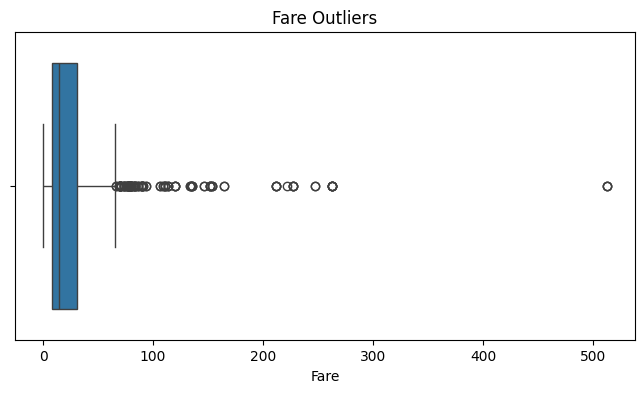

In [15]:

plt.figure(figsize=(8, 4))
sns.boxplot(x=titanicdata['Fare']).set_title('Fare Outliers')
from scipy import stats
z_scores = np.abs(stats.zscore(titanicdata['Fare']))
TitanicOutliers = titanicdata[z_scores > 3]
print(f"Found {len(TitanicOutliers)} fare Outliers")

**Insights from Fare Outlier Detection**

The boxplot shows a highly skewed distribution of fares, with most passengers paying under $100.

Several points far to the right represent extremely high fares (above $200, with a few around $500).

Using the z-score method, about 20 passengers were flagged as outliers.

These are not data errors but legitimate 1st-class suite fares (luxury cabins), so keeping them preserves important information about the relationship between fare, class, and survival.

This also highlights that Fare has a heavy right tail; if you plan to model it later, you may want to apply a log-transform to reduce skewness.

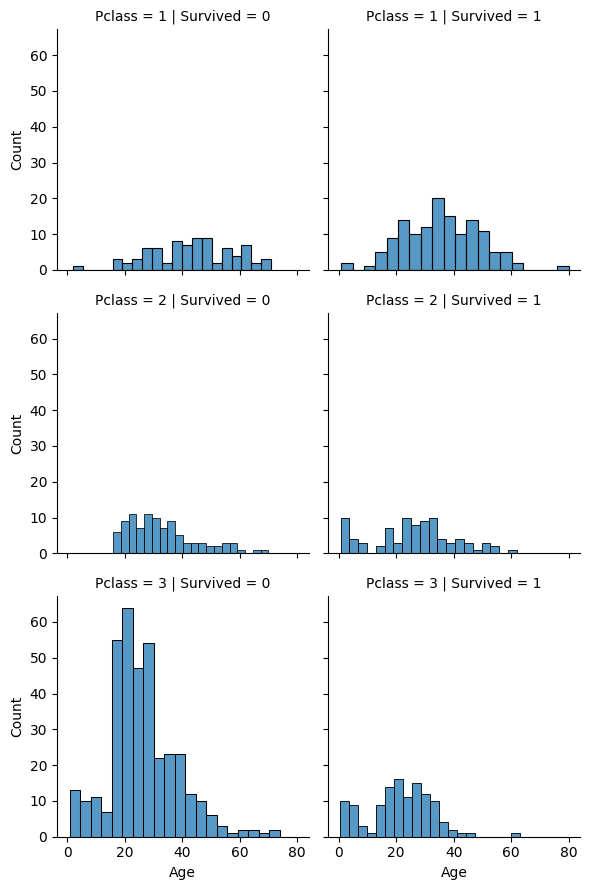

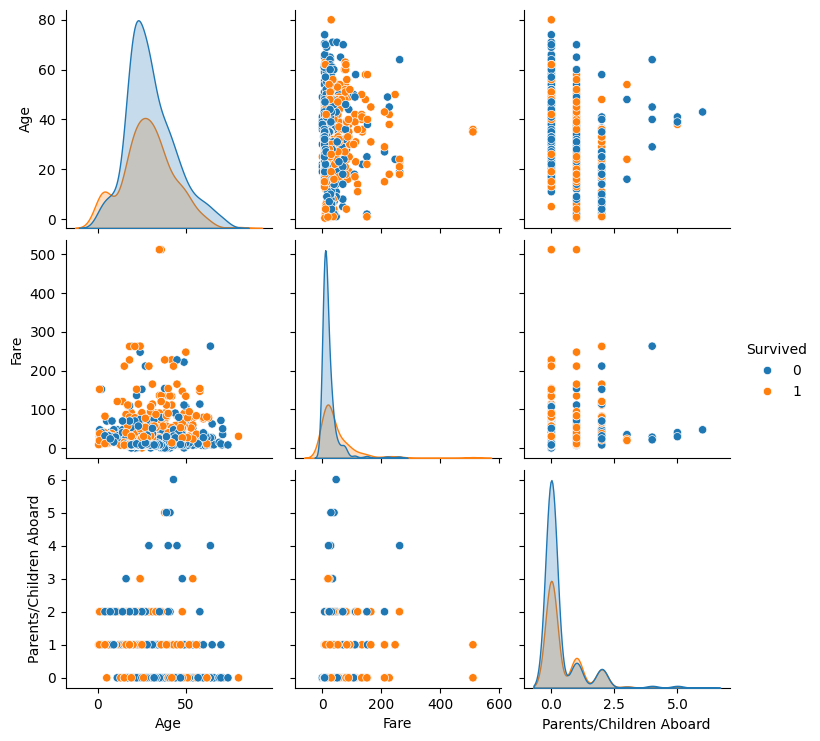

In [16]:

gt = sns.FacetGrid(titanicdata, col='Survived', row='Pclass', height=3)
gt.map(sns.histplot, 'Age', bins=20)
sns.pairplot(titanicdata[['Age', 'Fare', 'Parents/Children Aboard', 'Survived']], hue='Survived')


1. **FacetGrid (Age by Survival across Pclass)**

Pclass = 1:
Survivors and non-survivors are spread fairly evenly across ages.
But more younger and middle-aged passengers survived compared to older ones.
Pclass = 2:
Survivors cluster more in the younger to middle age range (~15–40).
Fewer older passengers in general.
Pclass = 3:
Most passengers are young (children to ~40).
Many young adults (~15–30) did not survive this indicates crowding & lower survival chances in 3rd class.
Some children survived (possibly due to “women and children first” policy).


 **Key insight**:
Survival odds are much better in 1st class, moderate in 2nd, and worst in 3rd class. Age plays a role too: children in 3rd class still had better survival chances than young adults in the same class.



2. **Pairplot (Age, Fare, Parents/Children Aboard vs Survived)**

Age vs Survival:
Survivors slightly skew younger.
Non-survivors cluster in the 20–40 range.
Fare vs Survival:
Survivors generally paid higher fares (correlated with 1st/2nd class).
Non-survivors cluster at low fares (3rd class).
Parents/Children Aboard vs Survival:
Survivors are more common when traveling with small family groups (1–3 children/parents).
Solo travelers or very large groups had lower survival chances.



** Key insight**:

Wealthier passengers (higher fares) survived more often.
Being in a family (especially with children) slightly increased survival probability.
Age and class strongly interact with survival.